In [138]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import re
from sklearn.preprocessing import StandardScaler


con = duckdb.connect('../capillary.db')

df = con.execute(""" 
                 SELECT id, value, pid,delimit_value, delimit_value2,analysis, protein_value, label, interpretation
                 FROM protein_data 
                 WHERE value IS NOT NULL
                 AND delimit_value IS NOT NULL
                 AND delimit_value2 IS NOT NULL
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()

pids = con.execute("SELECT DISTINCT pid FROM protein_data").df()


con.close()


def extract_fractions(delimit_list):
    fractions = []
    for item in delimit_list:
        match = re.search(r'(\d+\.?\d*)\s*%', str(item))
        if match:
            fractions.append(float(match.group(1)))
    return fractions

def extract_relevant_values(analysis_list: list[str], value_list: list[str], relevant: list[str]) -> np.array:
    protein_values = np.array([np.nan]*len(relevant))
    mapping = dict()

    if len(analysis_list) > len(value_list):
        raise Exception("Analysis list and value list must be of same length!")
    
    for i in range(len(analysis_list)):
        analysis = analysis_list[i].replace('*','')
        value = clean_value(value_list[i])
        mapping.update({analysis: value})

    for (i, analysis) in enumerate(relevant):
        protein_values[i] = mapping.get(analysis,np.nan)

    #får vi en nan får vi tyvärr hoppa över hela raden, jag kör pd.dropna senare
    if sum( (np.isnan(protein_values) == True) ) > 0:
        return np.nan

    return protein_values


def clean_value(val: str) -> float:
    if val is None or val == '' or val == 'NA' or val == 'NEG':
        return np.nan
    try:
        return float(str(val).replace('<', '').replace('>', '').strip())
    except:
        return np.nan
    

#hämta ut protein-value
relevant_anlysis = ['0054','0055','0056','0058','0062','0064','0065','0066']
df['protein_value'] = df.apply(
    lambda row: extract_relevant_values(
        row['analysis'], 
        row['protein_value'], 
        relevant_anlysis
    ), 
    axis=1
)


#value
df = df[ df['value'].apply(len) == 301 ] #vaska de rader där value inte har rätt längd (typ bara en korrupt rad)
df['value'] = df['value'].apply(lambda x: x[:300])

#delimit_value
#df['delimit_value'] = df['delimit_value'].apply(extract_fractions)
#df = df[ df['delimit_value'].apply(len) == 6]

#delimit_value2
#df = df[ df['delimit_value2'].apply(len) == 15]

#protein_value
#df = df.dropna()


X_curve     = np.array(df['value'].tolist(),         dtype=np.float32)  # (n, 300)
#X_fractions = np.array(df['delimit_value'].tolist(),  dtype=np.float32)  # (n, 6)
#X_delimit2  = np.array(df['delimit_value2'].tolist(), dtype=np.float32)  # (n, 15)
#X_protein   = np.array(df['protein_value'].tolist(),  dtype=np.float32)  # (n, 8)

X = X_curve
#X = np.concatenate([X_curve, X_fractions, X_delimit2,X_protein], axis=1)  # (n, 329)
y = np.array(df['label'].values, dtype=np.int64)


print(X.shape) 
print(y.shape)  

# Kolla att det inte finns NaN eller inf
print(f"NaN: {np.isnan(X).sum()}")
print(f"Inf: {np.isinf(X).sum()}")

# Kolla klassbalansen
unique, counts = np.unique(y, return_counts=True)
for val, count in zip(unique, counts):
    print(f"Label {val}: {count} ({count/len(y)*100:.1f}%)")



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(172511, 300)
(172511,)
NaN: 0
Inf: 0
Label 0: 121501 (70.4%)
Label 1: 38456 (22.3%)
Label 2: 8279 (4.8%)
Label 3: 2 (0.0%)
Label 4: 4058 (2.4%)
Label 5: 215 (0.1%)


In [139]:
valtrain_pids, test_pids = train_test_split(pids, test_size=0.15,random_state=25)
train_pids, val_pids = train_test_split(valtrain_pids, test_size=0.15,random_state=25)

test_rows = df[ df['pid'].isin(test_pids['pid'].tolist()) ]
val_rows = df[ df['pid'].isin(val_pids['pid'].tolist()) ]
train_rows = df[ df['pid'].isin(train_pids['pid'].tolist()) ]
train_rows = train_rows[train_rows['label'] == 0]
val_rows = val_rows[val_rows['label'] == 0]


id_train = train_rows['id'].to_numpy()
id_val   = val_rows['id'].to_numpy()
id_test  = test_rows['id'].to_numpy()


print(f"Antal fall med M-komponent i träningsdatan:{(train_rows['label'] == 1).sum()}")
print(f"Antal fall utan M-komponent i träningsdatan:{(train_rows['label'] == 0).sum()}")
print(f"Antal fall med M-komponent i testdatan:{(test_rows['label'] == 1).sum()}")
print(f"Antal fall utan M-komponent i testdatan:{(test_rows['label'] == 0).sum()}")

X_train = np.array(train_rows['value'].tolist(), dtype=np.float32)
X_val   = np.array(val_rows['value'].tolist(), dtype=np.float32)
X_test  = np.array(test_rows['value'].tolist(), dtype=np.float32)                           

y_train = np.array(train_rows['label'].values, dtype=np.int64)
y_val   = np.array(val_rows['label'].values,   dtype=np.int64)
y_test  = np.array(test_rows['label'].values,  dtype=np.int64)


X_train = torch.tensor(X_train)
X_val   = torch.tensor(X_val)
X_test  = torch.tensor(X_test)
y_train = torch.tensor(y_train)
y_val   = torch.tensor(y_val)
y_test  = torch.tensor(y_test)

print(f"Träning:    {len(X_train):>6} ({len(X_train)/len(df):.0%})")
print(f"Validering: {len(X_val):>6} ({len(X_val)/len(df):.0%})")
print(f"Test:       {len(X_test):>6} ({len(X_test)/len(df):.0%})")

print(torch.isnan(X_train).sum())
print(torch.isinf(X_train).sum())

Antal fall med M-komponent i träningsdatan:0
Antal fall utan M-komponent i träningsdatan:88004
Antal fall med M-komponent i testdatan:5736
Antal fall utan M-komponent i testdatan:18182
Träning:     88004 (51%)
Validering:  15315 (9%)
Test:        25884 (15%)
tensor(0)
tensor(0)


In [140]:
batch_sz = 512

# DataLoaders
train_dataloader = DataLoader(
    TensorDataset(X_train, y_train, torch.tensor(id_train)),
    batch_size=batch_sz,
    shuffle=True
)

val_dataloader = DataLoader(
    TensorDataset(X_val, y_val, torch.tensor(id_val)),
    batch_size=batch_sz
)

test_dataloader = DataLoader(
    TensorDataset(X_test, y_test, torch.tensor(id_test)),
    batch_size=batch_sz
)

for X, y,_ in val_dataloader:
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape}")
    break

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # ENCODER
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=7, stride=2, padding=3), # 300 -> 150
            nn.ReLU(),
            nn.Conv1d(8, 16, kernel_size=5, stride=2, padding=2), # 150 -> 75
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, stride=2, padding=1), # 75 -> 38
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 38, 16) # Bottleneck
        )
        
        # DECODER
        self.decoder = nn.Sequential(
            nn.Linear(16, 32 * 38),
            nn.ReLU(),
            nn.Unflatten(1, (32, 38)),
            nn.ConvTranspose1d(32, 16, 3, stride=2, padding=1, output_padding=0), # 38 -> 75
            nn.ReLU(),
            nn.ConvTranspose1d(16, 8, 5, stride=2, padding=2, output_padding=1), # 75 -> 150
            nn.ReLU(),
            nn.ConvTranspose1d(8, 1, 7, stride=2, padding=3, output_padding=1),  # 150 -> 300
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        z = self.encoder(x)
        out = self.decoder(z)
        return out.squeeze(1)
    
def weighted_mse_loss(input, target):
    # Skapa en viktmask: 1.0 för början, t.ex. 5.0 för Beta/Gamma (index 180-300)
    weights = torch.ones_like(input)
    weights[:, 200:] *= 5.0 
    loss = weights * (input - target) ** 2
    return loss.mean()
    
def train(train_dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0
    for X,_,_ in train_dataloader:
        X = X.to(device)

        # Compute prediction error
        reconstructed = model(X)
        loss = loss_fn(reconstructed, X)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    return total_loss / len(train_dataloader)


def test(dataloader, model, loss_fn):
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for X, _,_ in dataloader:
            X = X.to(device)
            reconstructed = model(X)
            test_loss += loss_fn(reconstructed, X).item()
    return test_loss / len(dataloader)


model = Autoencoder().to(device)

loss_fn = weighted_mse_loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.8)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Antal parametrar: {total_params:,}")

Shape of X: torch.Size([512, 300])
Shape of y: torch.Size([512])
Using mps device
Autoencoder(
  (encoder): Sequential(
    (0): Conv1d(1, 8, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): ReLU()
    (2): Conv1d(8, 16, kernel_size=(5,), stride=(2,), padding=(2,))
    (3): ReLU()
    (4): Conv1d(16, 32, kernel_size=(3,), stride=(2,), padding=(1,))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1216, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=1216, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(32, 38))
    (3): ConvTranspose1d(32, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (4): ReLU()
    (5): ConvTranspose1d(16, 8, kernel_size=(5,), stride=(2,), padding=(2,), output_padding=(1,))
    (6): ReLU()
    (7): ConvTranspose1d(8, 1, kernel_size=(7,), stride=(2,), padding=(3,), output_padding=(1,))
  )
)
Antal parametrar: 44,689


In [4]:
## KÖR DETTA BLOCKET FÖR ATT TRÄNA! Annars kör nästa block och läs in vikterna!
epochs = 1000
validation_losses = []
train_losses = []
best_train_loss = 10000
no_fails = 0
best_validation_loss = 10000

for t in range(epochs):
    train_loss = train(train_dataloader, model, loss_fn, optimizer)
    avg_loss = test(val_dataloader, model, loss_fn)
    scheduler.step()
    print(f"Epoch {t:>3} | train loss: {train_loss:.4f} | val loss: {avg_loss:.4f}")
    train_losses.append(train_loss)
    validation_losses.append(avg_loss)

    if avg_loss < best_validation_loss:
        best_validation_loss = avg_loss
        torch.save(model.state_dict(), "auto_encoder_model.pth")
        print("-> ny bästa model! Saved PyTorch Model State to auto_encoder_model.pth")

    if train_loss < best_train_loss:
        best_train_loss = train_loss
        no_fails = 0
        
    else:
        no_fails += 1
    
    if no_fails == 10:
        break
print("Done!")

torch.save(model.state_dict(), "auto_encoder_model.pth")
print("Saved PyTorch Model State to auto_encoder_model.pth")


KeyboardInterrupt: 

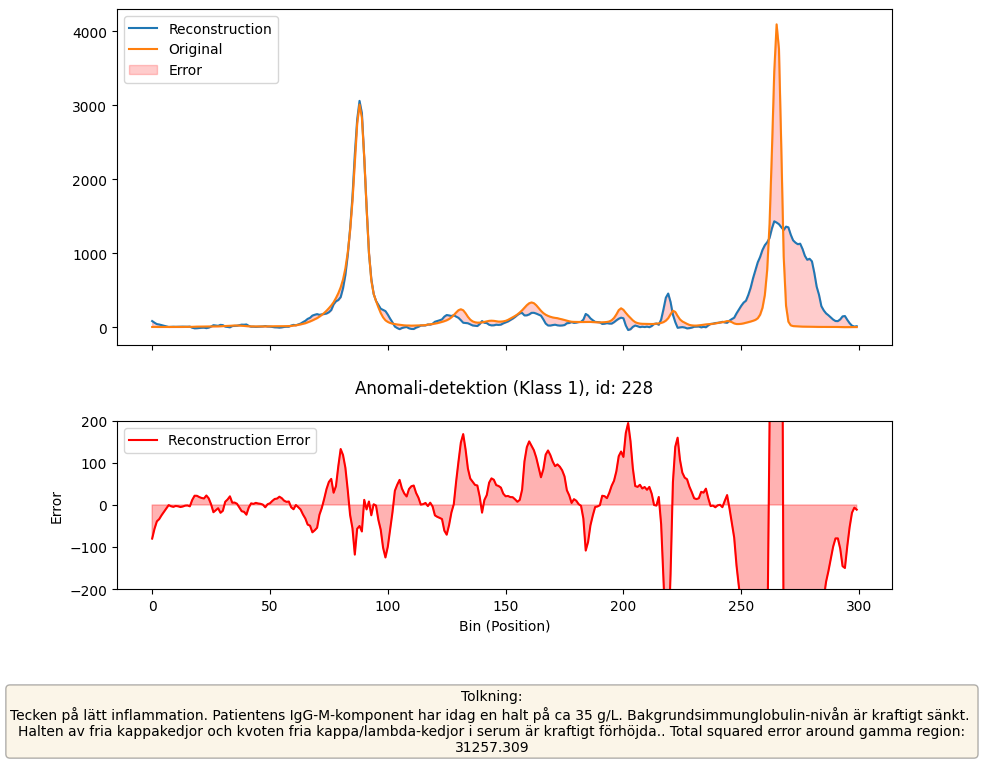

In [141]:
import matplotlib.pyplot as plt
import random

model.load_state_dict(torch.load("auto_encoder_model.pth", weights_only=True))

model.eval()
with torch.no_grad():
    # Hämta en batch från test_set (gärna en med en känd anomali)
    X, y, id = next(iter(test_dataloader))
    X = X.to(device)
    reconstruction = model(X)


    indices = (y == 1).nonzero(as_tuple=True)[0].tolist()
    idx = random.choice(indices)
    id = id[idx].item()
    row = df[df['id'] == id]

    # 1. Gör hela figuren högre (8 istället för 5-6)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

    # 2. Skapa ett "subplot"-system som lämnar tomrum längst ner
    # .subplots_adjust gör att vi manuellt kan dra upp bottenkanten på grafen
    plt.title(f"Anomali-detektion (Klass {y[idx]}), id: {id}", pad=20)
    plt.subplots_adjust(bottom=0.3,hspace=0.3) 

    ax1.plot(reconstruction[idx].cpu(), label='Reconstruction', linewidth=1.5)
    ax1.plot(X[idx, :].cpu(), label='Original', linewidth=1.5)
    ax1.fill_between(range(300), X[idx, :300].cpu(), reconstruction[idx].cpu(), color='red', alpha=0.2, label='Error')

    ax1.legend()



    error = (X[idx, :].cpu() - reconstruction[idx].cpu())
    ax2.plot(error, color='red', label='Reconstruction Error')
    ax2.fill_between(range(300), error, color='red', alpha=0.3)
    ax2.set_ylabel("Error")
    ax2.set_xlabel("Bin (Position)")
    ax2.legend()
    ax2.set_ylim((-200,200))

    # Hämta ren text
    total_squared_error = sum( (X[idx, 225:275].cpu() - reconstruction[idx,225:275].cpu())**2  ) / 1000
    tolkning_text = str(row['interpretation'].values[0])
    tolkning_text = tolkning_text + ". Total squared error around gamma region: " + str(total_squared_error.numpy())

    # 3. Använd y-koordinat som är lägre (t.ex. 0.15) och sätt va='top'
    # wrap=True fungerar bäst om vi anger en bredd för texten (width)
    plt.figtext(0.5, 0.20, f"Tolkning:\n{tolkning_text}", 
                wrap=True, 
                horizontalalignment='center', 
                verticalalignment='top',
                fontsize=10, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.show()
    

In [142]:
# Analys av hur träningen gick
import matplotlib.pyplot as plt

plt.plot(validation_losses, label='validation loss')
plt.plot(train_losses, label = 'train loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')
plt.grid(True)
plt.show()

NameError: name 'validation_losses' is not defined

In [143]:
## Del 2: användning av auto-encodern

con = duckdb.connect('../capillary.db')

df = con.execute(""" 
                 SELECT id, value, pid,delimit_value, delimit_value2,analysis, protein_value, label, interpretation
                 FROM protein_data 
                 WHERE value IS NOT NULL
                 AND delimit_value IS NOT NULL
                 AND delimit_value2 IS NOT NULL
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()

pids = con.execute("SELECT DISTINCT pid FROM protein_data").df()


con.close()

df = df[ df['value'].apply(len) == 301 ] #vaska de rader där value inte har rätt längd (typ bara en korrupt rad)
df['value'] = df['value'].apply(lambda x: x[:300])

valtrain_pids, test_pids = train_test_split(pids, test_size=0.15,random_state=25)
df = df[ df['pid'].isin(valtrain_pids['pid'].tolist()) ]



X_curve  = np.array(df['value'].tolist(), dtype=np.float32)  # (n, 300)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [151]:
##I den här delen tar vi all data och kör igenom nätverket samt räknar ut de kvadrerade rekonstruktionsfelen
def get_all_reconstructions(model, X_data, batch_size=512):
    model.eval()
    reconstructions = []
    X_tensor = torch.tensor(X_data, dtype=torch.float32)

    dataset = TensorDataset(X_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    with torch.no_grad():
        for batch in loader:
            inputs = batch[0].to(device)
            outputs = model(inputs)
            reconstructions.append(outputs.cpu().numpy())
            
    # Slå ihop alla batchar till en enda matris (N, 300)
    return np.concatenate(reconstructions, axis=0).squeeze()

reconstructions = get_all_reconstructions(model,X_curve)
errors = X_curve - reconstructions
squared_errors = np.power((X_curve-reconstructions),2)

df['reconstructions'] = list(reconstructions)
df['errors'] = list(errors)
df['squared_errors'] = list(squared_errors)
df['total_squared_error'] = df['squared_errors'].apply(np.sum) / 1000
df['total_squared_error_gamma_region'] = df['squared_errors'].apply(lambda x: np.sum(x[190:270])) / 1000
print(f"minimal TSE: {np.min(df['total_squared_error'])} | maximal TSE: {np.max(df['total_squared_error'])} | average TSE: {np.mean(df['total_squared_error'])}")

print(f"Gamma region: minimal TSE: {np.min(df['total_squared_error_gamma_region'])} | maximal TSE: {np.max(df['total_squared_error_gamma_region'])} | average TSE: {np.mean(df['total_squared_error_gamma_region'])}")


minimal TSE: 5.5244975090026855 | maximal TSE: 102489.5078125 | average TSE: 1181.84423828125
Gamma region: minimal TSE: 0.507140040397644 | maximal TSE: 69931.4296875 | average TSE: 793.7567749023438


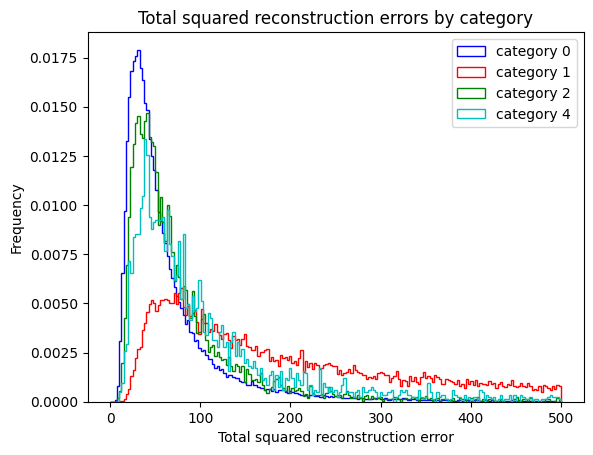

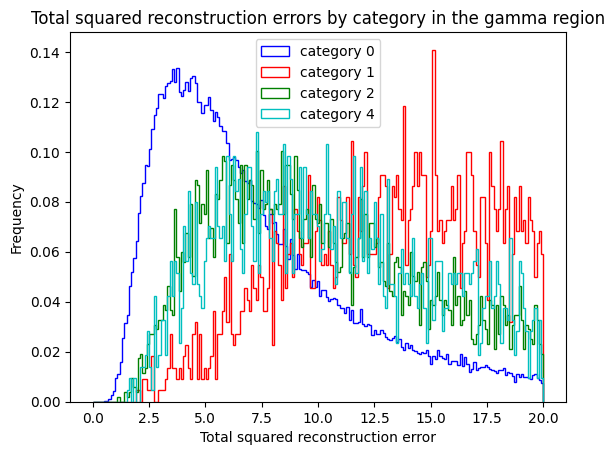

{'whiskers': [<matplotlib.lines.Line2D at 0x30c08dbd0>,
 'caps': [<matplotlib.lines.Line2D at 0x30c08d950>,
 'boxes': [<matplotlib.lines.Line2D at 0x30c08dd10>,
 'medians': [<matplotlib.lines.Line2D at 0x30c08d590>,
 'fliers': [<matplotlib.lines.Line2D at 0x30c08d310>,
 'means': []}

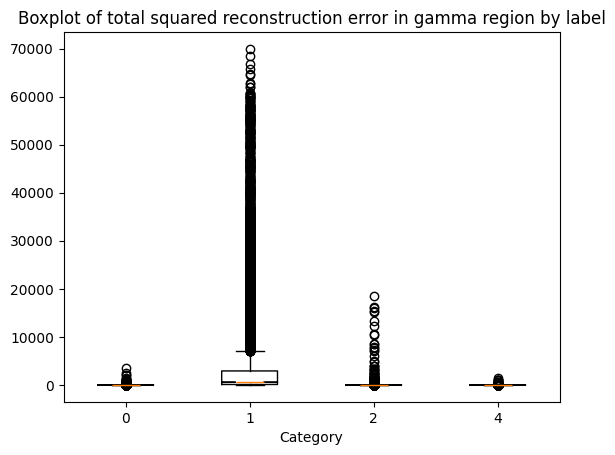

In [152]:
##visualisering av datan

cat_0 = df.loc[ df['label'] == 0, 'total_squared_error']
cat_1 = df.loc[ df['label'] == 1, 'total_squared_error']
cat_2 = df.loc[ df['label'] == 2, 'total_squared_error']
cat_4 = df.loc[ df['label'] == 4, 'total_squared_error']


bins = np.linspace(0,500,200)

plt.hist(cat_0,bins=bins,color='b',histtype='step',density=True,label='category 0')
plt.hist(cat_1,bins=bins,color='r',histtype='step',density=True,label='category 1')
plt.hist(cat_2,bins=bins,color='g',histtype='step',density=True,label='category 2')
plt.hist(cat_4,bins=bins,color='c',histtype='step',density=True,label='category 4')
plt.xlabel('Total squared reconstruction error')
plt.ylabel('Frequency')
plt.title("Total squared reconstruction errors by category")
plt.legend()
plt.show()

cat_0 = df.loc[ df['label'] == 0, 'total_squared_error_gamma_region']
cat_1 = df.loc[ df['label'] == 1, 'total_squared_error_gamma_region']
cat_2 = df.loc[ df['label'] == 2, 'total_squared_error_gamma_region']
cat_4 = df.loc[ df['label'] == 4, 'total_squared_error_gamma_region']


bins = np.linspace(0,20,200)

plt.figure()
plt.hist(cat_0,bins=bins,color='b',histtype='step',density=True,label='category 0')
plt.hist(cat_1,bins=bins,color='r',histtype='step',density=True,label='category 1')
plt.hist(cat_2,bins=bins,color='g',histtype='step',density=True,label='category 2')
plt.hist(cat_4,bins=bins,color='c',histtype='step',density=True,label='category 4')
plt.xlabel('Total squared reconstruction error')
plt.ylabel('Frequency')
plt.title("Total squared reconstruction errors by category in the gamma region")
plt.legend()
plt.show()

plt.figure()
plt.title("Boxplot of total squared reconstruction error in gamma region by label")
plt.xlabel("Category")
plt.boxplot( (cat_0,cat_1,cat_2,cat_4),label=(0,1,2,4),tick_labels=(0,1,2,4),notch=True)

Maximum accuracy: 94.560% at threshold: 44
False positive rate at maximum accuracy: 2.167%
False negative rate at maximum accuracy: 15.794%
False positive rate at 3% false negative rate: 17.174%
threshold at 3% false negative rate: 14


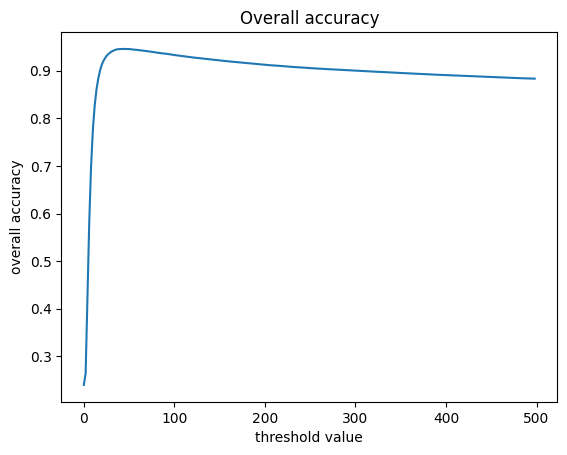

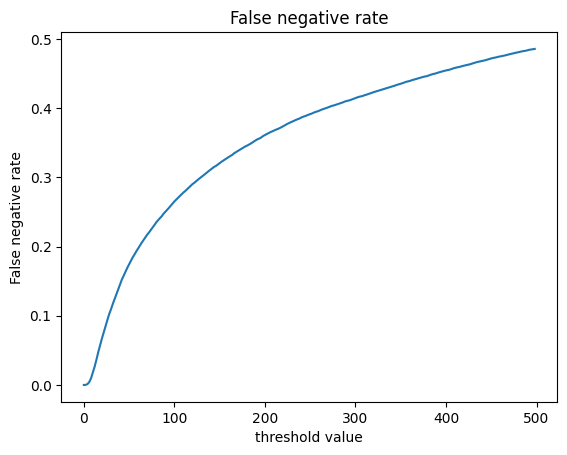

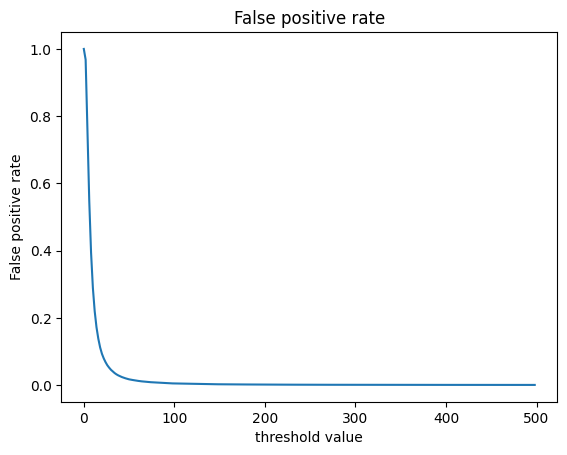

In [153]:
## test att använda tröskelvärden för klassificering

thresholds = range(0,500,2)
rows = df[ (df['label'] == 0) | (df['label'] == 1)]
fn_rates = []
fp_rates = []
accuracies = []
n = len(rows)
n_pos = (rows['label'] == 1).sum()
n_neg = (rows['label'] == 0).sum()

for threshold in thresholds:
    
    predictions = (rows['total_squared_error_gamma_region'] >= threshold).astype(int)
    truth = rows['label']
    fn_count = ((truth == 1) & (predictions == 0)).sum()
    fp_count = ( (truth == 0) & (predictions == 1)).sum()
    correct_count = (predictions == truth).sum()
    fn_rates.append(fn_count/n_pos)
    fp_rates.append(fp_count/n_neg)
    accuracies.append(correct_count/n)


plt.figure()
plt.plot(thresholds,accuracies)
plt.ylabel("overall accuracy")
plt.xlabel("threshold value")
plt.title("Overall accuracy")

plt.figure()
plt.plot(thresholds,fn_rates)
plt.ylabel("False negative rate")
plt.xlabel("threshold value")
plt.title("False negative rate")

plt.figure()
plt.plot(thresholds,fp_rates)
plt.ylabel("False positive rate")
plt.xlabel("threshold value")
plt.title("False positive rate")

fn_rates = np.array(fn_rates,dtype=float)

print(f"Maximum accuracy: {np.max(accuracies)*100:.3f}% at threshold: {thresholds[np.argmax(accuracies)]}")
print(f"False positive rate at maximum accuracy: {fp_rates[np.argmax(accuracies)]*100:.3f}%")
print(f"False negative rate at maximum accuracy: {fn_rates[np.argmax(accuracies)]*100:.3f}%")

print(f"False positive rate at 3% false negative rate: {fp_rates[np.where(fn_rates >= 0.03 )[0][0] ]*100:.3f}%")
print(f"threshold at 3% false negative rate: {thresholds[np.where(fn_rates >= 0.03)[0][0]]}")


Maximum accuracy: 91.973% at lower bound: 229


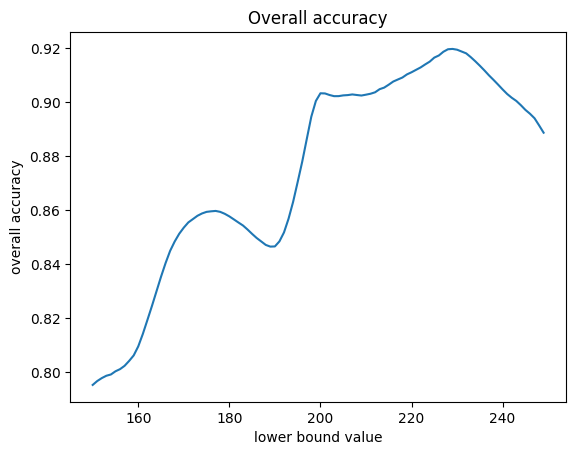

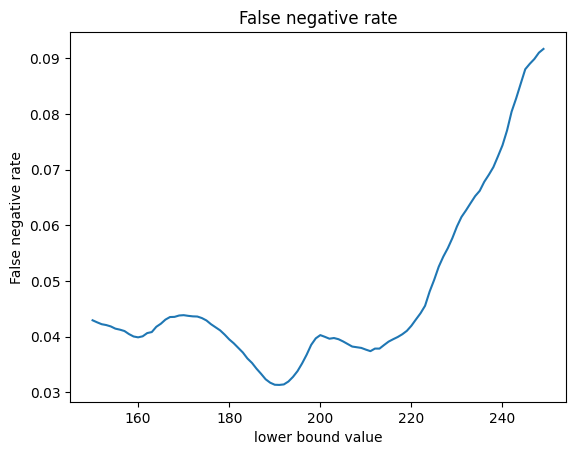

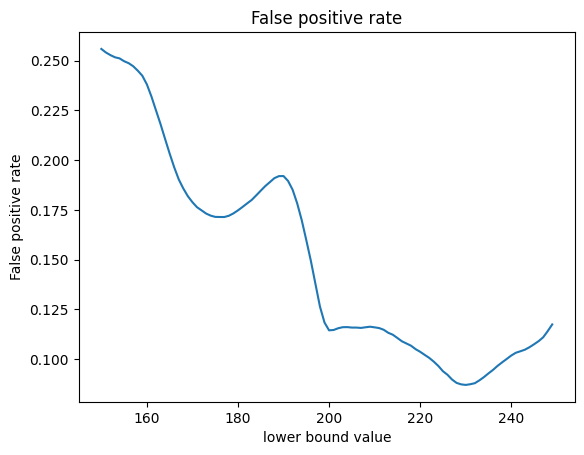

In [149]:
## optimera fram nedre gränsen

threshold = 10
fn_rates = []
fp_rates = []
accuracies = []
boundaries = range(150,250,1)
upper_bound=275

for bound in boundaries:
    tse = rows['squared_errors'].apply(lambda x: np.sum( np.array(x)[bound:upper_bound])) / 1000
    boundary_width = upper_bound-bound
    weighted_threshold = (boundary_width/70)**1.5 * 10
    predictions = (tse >= weighted_threshold).astype(int)
    truth = rows['label']
    fn_count = ((truth == 1) & (predictions == 0)).sum()
    fp_count = ( (truth == 0) & (predictions == 1)).sum()
    correct_count = (predictions == truth).sum()
    fn_rates.append(fn_count/n_pos)
    fp_rates.append(fp_count/n_neg)
    accuracies.append(correct_count/n)


plt.figure()
plt.plot(boundaries,accuracies)
plt.ylabel("overall accuracy")
plt.xlabel("lower bound value")
plt.title("Overall accuracy")

plt.figure()
plt.plot(boundaries,fn_rates)
plt.ylabel("False negative rate")
plt.xlabel("lower bound value")
plt.title("False negative rate")

plt.figure()
plt.plot(boundaries,fp_rates)
plt.ylabel("False positive rate")
plt.xlabel("lower bound value")
plt.title("False positive rate")

fn_rates = np.array(fn_rates,dtype=float)

print(f"Maximum accuracy: {np.max(accuracies)*100:.3f}% at lower bound: {boundaries[np.argmax(accuracies)]}")


Maximum accuracy: 90.800% at upper bound: 253


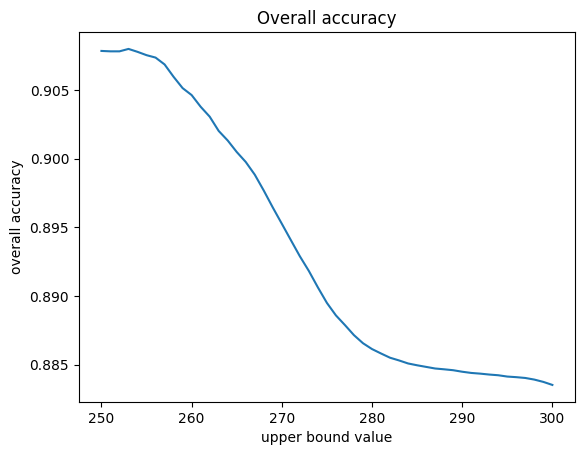

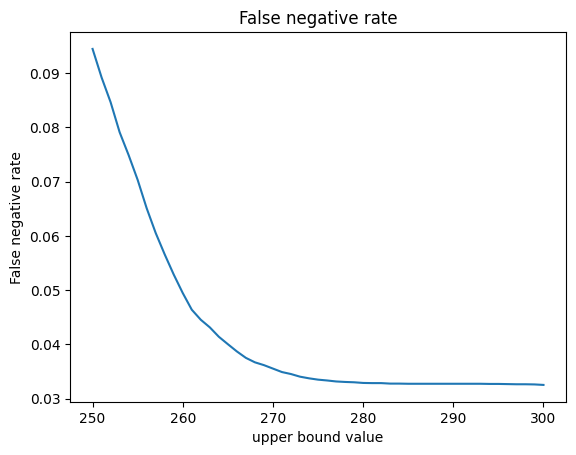

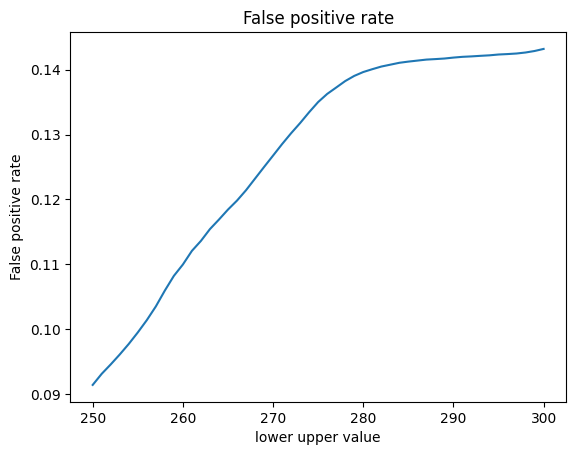

In [ ]:
## optimera fram övre gränsen

threshold = 10
fn_rates = []
fp_rates = []
accuracies = []
boundaries = range(250,301,1)
lower_bound=200

for bound in boundaries:
    tse = rows['squared_errors'].apply(lambda x: np.sum( np.array(x)[lower_bound:bound])) / 1000
    boundary_width = bound-lower_bound
    weighted_threshold = (boundary_width/70)**1.5 * 10
    predictions = (tse >= weighted_threshold).astype(int)
    truth = rows['label']
    fn_count = ((truth == 1) & (predictions == 0)).sum()
    fp_count = ( (truth == 0) & (predictions == 1)).sum()
    correct_count = (predictions == truth).sum()
    fn_rates.append(fn_count/n_pos)
    fp_rates.append(fp_count/n_neg)
    accuracies.append(correct_count/n)


plt.figure()
plt.plot(boundaries,accuracies)
plt.ylabel("overall accuracy")
plt.xlabel("upper bound value")
plt.title("Overall accuracy")

plt.figure()
plt.plot(boundaries,fn_rates)
plt.ylabel("False negative rate")
plt.xlabel("upper bound value")
plt.title("False negative rate")

plt.figure()
plt.plot(boundaries,fp_rates)
plt.ylabel("False positive rate")
plt.xlabel("lower upper value")
plt.title("False positive rate")

fn_rates = np.array(fn_rates,dtype=float)

print(f"Maximum accuracy: {np.max(accuracies)*100:.3f}% at upper bound: {boundaries[np.argmax(accuracies)]}")


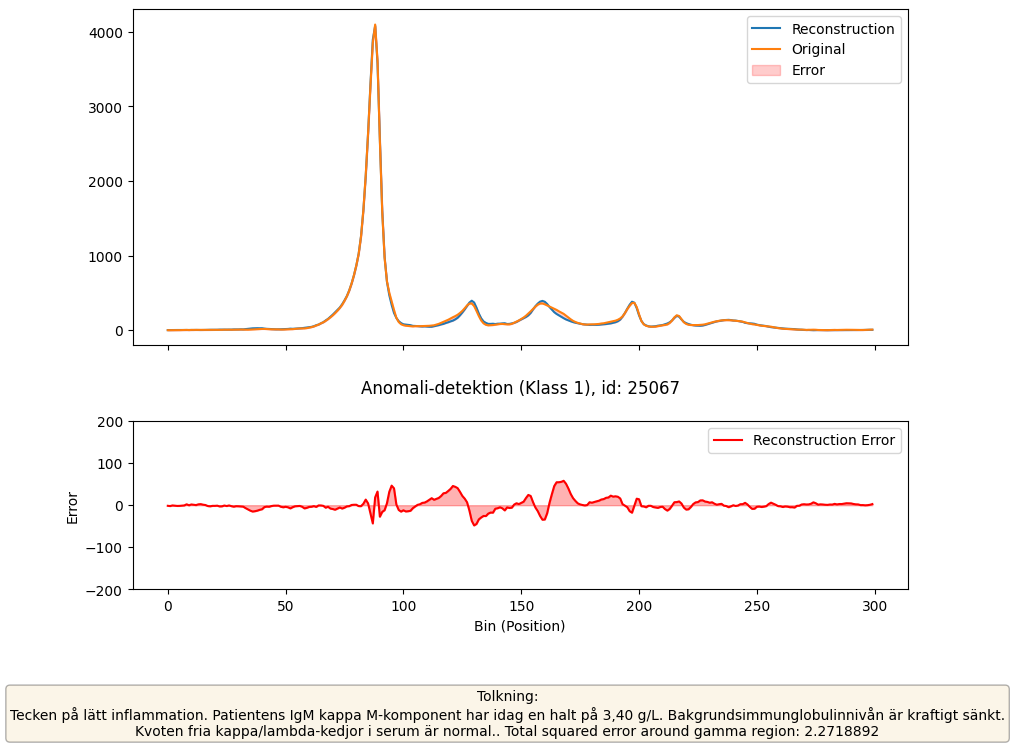

In [108]:
##Nu sorterar vi utifrån hur stort rekonstruktionsfel kurvan har i gammaregionen. index 0 har minsta, och sen stiger det.

sorted = df.sort_values('total_squared_error_gamma_region').reset_index(drop=True)

idx = len(sorted) - 10002 #Välj här!

subset = sorted[sorted['label'] == 1]
idx = subset['total_squared_error_gamma_region'].nsmallest(1000).index[30] #här kan man plocka outliers

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True, 
                            gridspec_kw={'height_ratios': [2, 1]})

# 2. Skapa ett "subplot"-system som lämnar tomrum längst ner
# .subplots_adjust gör att vi manuellt kan dra upp bottenkanten på grafen
plt.title(f"Anomali-detektion (Klass {sorted.loc[idx,'label']}), id: {sorted.loc[idx,'id']}", pad=20)
plt.subplots_adjust(bottom=0.3,hspace=0.3) 

ax1.plot(sorted.loc[idx,'reconstructions'], label='Reconstruction', linewidth=1.5)
ax1.plot(sorted.loc[idx,'value'], label='Original', linewidth=1.5)
ax1.fill_between(range(300), sorted.loc[idx,'value'], sorted.loc[idx,'reconstructions'], color='red', alpha=0.2, label='Error')

ax1.legend()


ax2.plot(sorted.loc[idx,'errors'], color='red', label='Reconstruction Error')
ax2.fill_between(range(300), sorted.loc[idx,'errors'], color='red', alpha=0.3)
ax2.set_ylabel("Error")
ax2.set_xlabel("Bin (Position)")
ax2.legend()
ax2.set_ylim((-200,200))

# Hämta ren text
tolkning_text = sorted.loc[idx,'interpretation'] + ". Total squared error around gamma region: " + str(sorted.loc[idx,'total_squared_error_gamma_region'])

# 3. Använd y-koordinat som är lägre (t.ex. 0.15) och sätt va='top'
# wrap=True fungerar bäst om vi anger en bredd för texten (width)
plt.figtext(0.5, 0.20, f"Tolkning:\n{tolkning_text}", 
            wrap=True, 
            horizontalalignment='center', 
            verticalalignment='top',
            fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.show()
    

Coeff for tse: 0.08
Odds ratio for tse: 1.08
                  precision    recall  f1-score   support

  no m-component       0.94      0.99      0.97     25977
with m-component       0.98      0.80      0.88      8088

        accuracy                           0.95     34065
       macro avg       0.96      0.90      0.92     34065
    weighted avg       0.95      0.95      0.95     34065



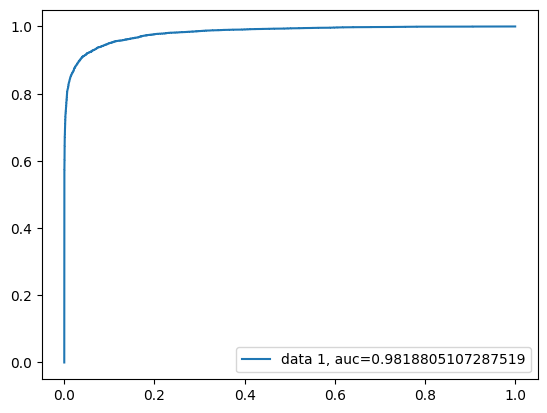

[[0.93735267 0.06264733]]


In [135]:
## Test av logistisk regression
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

X = np.array(rows['total_squared_error_gamma_region']).reshape(-1,1)
y = np.array(rows['label'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=25)


model = LogisticRegression().fit(X_train, y_train)

# Let's consider the first feature: mean radius
coef = model.coef_[0][0]
oddsratio = np.exp(coef)

print(f"Coeff for tse: {coef:.2f}")
print(f"Odds ratio for tse: {oddsratio:.2f}")
# fit the model with data

y_pred = model.predict(X_test)

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

from sklearn.metrics import classification_report
target_names = ['no m-component', 'with m-component']
print(classification_report(y_test, y_pred, target_names=target_names))

y_pred_proba = model.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()
import joblib

joblib.dump(model, 'logistic_regression.pkl')

print(model.predict_proba(np.array([10]).reshape(-1,1) ))


In [ ]:
## NEDANFÖR HÄR TESTADE JAG ATT MHA NEURALA NÄTVERK KLASSIFICERA. Funkade sådär. Ignorera


valtrain_pids, test_pids = train_test_split(pids, test_size=0.15,random_state=25)
train_pids, val_pids = train_test_split(valtrain_pids, test_size=0.15,random_state=25)

test_rows = df[ df['pid'].isin(test_pids['pid'].tolist()) ]
val_rows = df[ df['pid'].isin(val_pids['pid'].tolist()) ]
train_rows = df[ df['pid'].isin(train_pids['pid'].tolist()) ]
train_rows = train_rows[ (train_rows['label'] == 0) | (train_rows['label'] == 1)  ]
val_rows = val_rows[ (val_rows['label'] == 0) | (val_rows['label'] == 1)  ]


id_train = train_rows['id'].to_numpy()
id_val   = val_rows['id'].to_numpy()
id_test  = test_rows['id'].to_numpy()


print(f"Antal fall med M-komponent i träningsdatan:{(train_rows['label'] == 1).sum()}")
print(f"Antal fall utan M-komponent i träningsdatan:{(train_rows['label'] == 0).sum()}")
print(f"Antal fall med M-komponent i testdatan:{(test_rows['label'] == 1).sum()}")
print(f"Antal fall utan M-komponent i testdatan:{(test_rows['label'] == 0).sum()}")

X_train = np.array(train_rows['errors'].tolist(), dtype=np.float32)
X_val   = np.array(val_rows['errors'].tolist(), dtype=np.float32)
X_test  = np.array(test_rows['errors'].tolist(), dtype=np.float32)                           

y_train = np.array(train_rows['label'].values, dtype=np.int64)
y_val   = np.array(val_rows['label'].values,   dtype=np.int64)
y_test  = np.array(test_rows['label'].values,  dtype=np.int64)


X_train = torch.tensor(X_train)
X_val   = torch.tensor(X_val)
X_test  = torch.tensor(X_test)
y_train = torch.tensor(y_train)
y_val   = torch.tensor(y_val)
y_test  = torch.tensor(y_test)

print(f"Träning:    {len(X_train):>6} ({len(X_train)/len(df):.0%})")
print(f"Validering: {len(X_val):>6} ({len(X_val)/len(df):.0%})")
print(f"Test:       {len(X_test):>6} ({len(X_test)/len(df):.0%})")

print(torch.isnan(X_train).sum())
print(torch.isinf(X_train).sum())

Antal fall med M-komponent i träningsdatan:28138
Antal fall utan M-komponent i träningsdatan:87926
Antal fall med M-komponent i testdatan:5427
Antal fall utan M-komponent i testdatan:17896
Träning:    116064 (67%)
Validering:  20570 (12%)
Test:        25199 (15%)
tensor(0)
tensor(0)


In [218]:
batch_sz = 512

# DataLoaders
train_dataloader = DataLoader(
    TensorDataset(X_train, y_train, torch.tensor(id_train)),
    batch_size=batch_sz,
    shuffle=True
)

val_dataloader = DataLoader(
    TensorDataset(X_val, y_val, torch.tensor(id_val)),
    batch_size=batch_sz
)

test_dataloader = DataLoader(
    TensorDataset(X_test, y_test, torch.tensor(id_test)),
    batch_size=batch_sz
)

for X, y,_ in val_dataloader:
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape}")
    break

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1,out_channels=32,kernel_size=7,padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32,64,kernel_size=5,padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64,128,kernel_size=3,padding=1),
            nn.ReLU()
        )

        self.gap = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64,2)
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x,1)
        x = self.classifier(x)
        return x
    
def train(train_dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0
    for batch, (X, y,_) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    return total_loss / len(train_dataloader)


def test(test_dataloader, model, loss_fn):
    size = len(test_dataloader.dataset)
    num_batches = len(test_dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y,_ in test_dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    return (100*correct,test_loss)


model = NeuralNetwork().to(device)
pos_weight = torch.tensor([1.0, 6], dtype=torch.float32).to(device)

loss_fn = nn.CrossEntropyLoss(weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.8)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Antal parametrar: {total_params:,}")

Shape of X: torch.Size([512, 300])
Shape of y: torch.Size([512])
Using mps device
NeuralNetwork(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
  )
  (gap): AdaptiveAvgPool1d(output_size=1)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
Antal parametrar: 43,650


In [219]:
## KÖR DETTA BLOCKET FÖR ATT TRÄNA! Annars kör nästa block och läs in vikterna!
epochs = 1000
accuracies = []
validation_losses = []
train_losses = []
best_validation_loss = 10000
no_fails = 0

for t in range(epochs):
    train_loss = train(train_dataloader, model, loss_fn, optimizer)
    (accuracy,avg_loss) = test(val_dataloader, model, loss_fn)
    scheduler.step()
    print(f"Epoch {t:>3} | train loss: {train_loss:.4f} | val loss: {avg_loss:.4f} | val acc: {accuracy:.1f}%")
    train_losses.append(train_loss)
    accuracies.append(accuracy)
    validation_losses.append(avg_loss)

    if avg_loss < best_validation_loss:
        best_validation_loss = avg_loss
        no_fails = 0
        torch.save(model.state_dict(), "classifier.pth")
        print("-> ny bästa model! Saved PyTorch Model State to classifier.pth")
    else:
        no_fails += 1
    
    if no_fails == 5:
        break
print("Done!")

torch.save(model.state_dict(), "classifier.pth")
print("Saved PyTorch Model State to classifier.pth")


Epoch   0 | train loss: 0.3137 | val loss: 0.2403 | val acc: 92.2%
-> ny bästa model! Saved PyTorch Model State to classifier.pth
Epoch   1 | train loss: 0.2117 | val loss: 0.2023 | val acc: 94.9%
-> ny bästa model! Saved PyTorch Model State to classifier.pth
Epoch   2 | train loss: 0.1819 | val loss: 0.1758 | val acc: 93.7%
-> ny bästa model! Saved PyTorch Model State to classifier.pth
Epoch   3 | train loss: 0.1606 | val loss: 0.1701 | val acc: 92.7%
-> ny bästa model! Saved PyTorch Model State to classifier.pth
Epoch   4 | train loss: 0.1519 | val loss: 0.1595 | val acc: 94.0%
-> ny bästa model! Saved PyTorch Model State to classifier.pth
Epoch   5 | train loss: 0.1427 | val loss: 0.1579 | val acc: 93.0%
-> ny bästa model! Saved PyTorch Model State to classifier.pth
Epoch   6 | train loss: 0.1396 | val loss: 0.1647 | val acc: 91.2%
Epoch   7 | train loss: 0.1337 | val loss: 0.1430 | val acc: 95.7%
-> ny bästa model! Saved PyTorch Model State to classifier.pth
Epoch   8 | train loss:

In [221]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load("classifier.pth", weights_only=True))

# Samla alla prediktioner

THRESHOLD = 0.2

model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for X, y,_ in test_dataloader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        probs = torch.softmax(logits, dim=1)[:, 1]
        pred = model(X)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs >= THRESHOLD).astype(int)

accuracy = sum(all_preds == all_labels)/len(all_preds)
missed_positives = sum( (all_labels == 1) & (all_preds == 0))/len(all_preds)
false_positives = sum( (all_labels == 0) & (all_preds == 1))/len(all_preds)

# Hitta FN
fn_idx = np.where((all_labels == 1) & (all_preds == 0))[0]
print(f"Antal FN: {len(fn_idx)}")
# Rapport
print(classification_report(all_labels, all_preds))
print(confusion_matrix(all_labels, all_preds))
print(f"Overall accuracy (using threshold): {100*accuracy:.2f}%")
print(f"False negative rate, i.e dangerous percentage (using threshold): {100*missed_positives:.2f}%")
print(f"False positive rate, i.e unneccesary alarm (using threshold): {100*false_positives:.2f}%")


Antal FN: 192
              precision    recall  f1-score   support

           0       0.93      0.91      0.92     17896
           1       0.68      0.96      0.80      5427
           2       0.00      0.00      0.00      1233
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00       611
           5       0.00      0.00      0.00        31

    accuracy                           0.86     25199
   macro avg       0.27      0.31      0.29     25199
weighted avg       0.81      0.86      0.83     25199

[[16343  1553     0     0     0     0]
 [  192  5235     0     0     0     0]
 [  594   639     0     0     0     0]
 [    1     0     0     0     0     0]
 [  345   266     0     0     0     0]
 [   13    18     0     0     0     0]]
Overall accuracy (using threshold): 85.63%
False negative rate, i.e dangerous percentage (using threshold): 0.76%
False positive rate, i.e unneccesary alarm (using threshold): 6.16%


/Users/assarleideman/exjobb/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/assarleideman/exjobb/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/assarleideman/exjobb/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

Antal FN: 1369


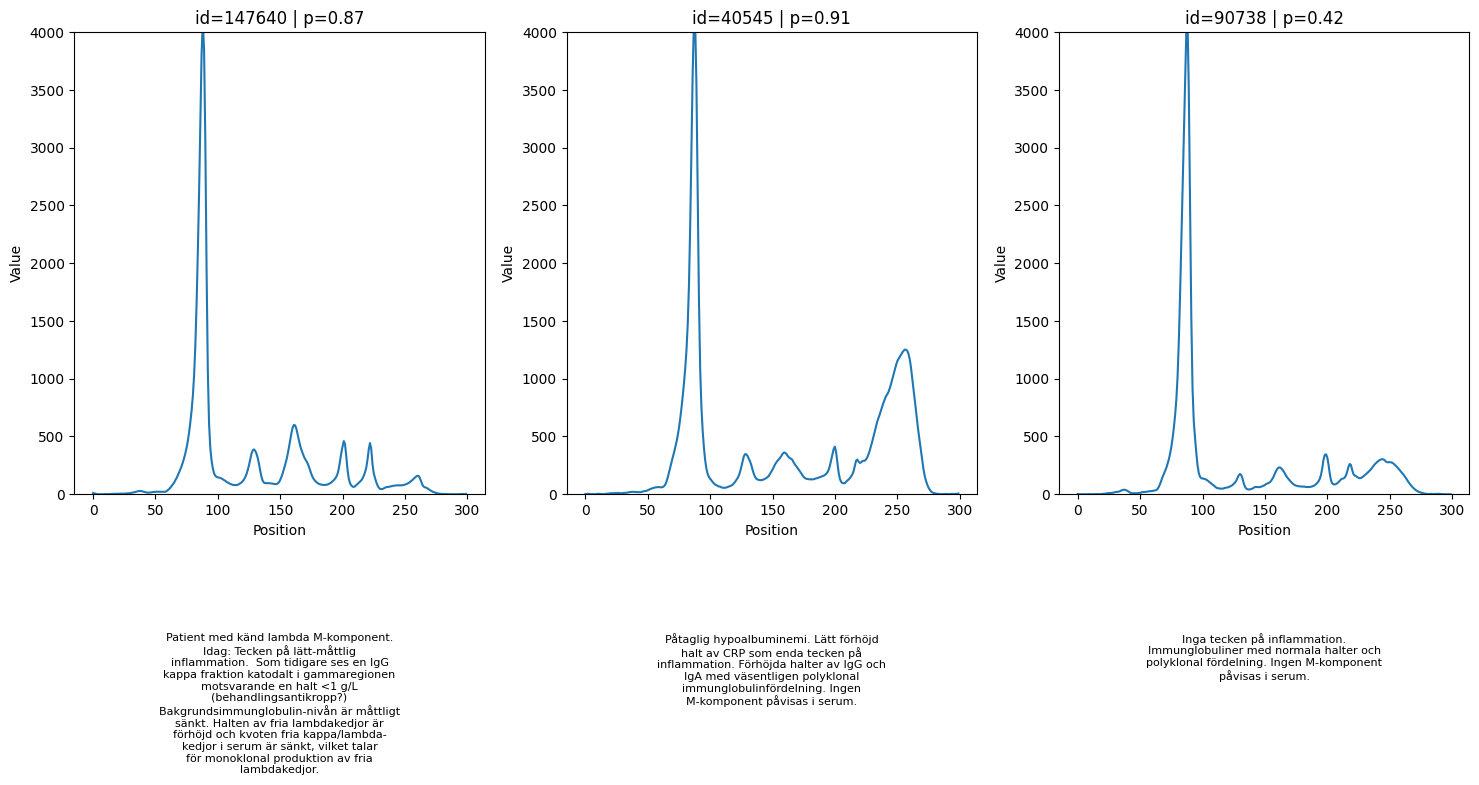

<Figure size 640x480 with 0 Axes>

In [225]:
import textwrap



THRESHOLD = 0.2
model.eval()

all_probs = []
all_labels = []
all_ids = []

with torch.no_grad():
    for X, y, ids in val_dataloader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        probs = torch.softmax(logits, dim=1)[:, 1]

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
        all_ids.extend(ids.cpu().numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
all_ids    = np.array(all_ids)

all_preds  = (all_probs >= THRESHOLD).astype(int)

fn_idx = np.where((all_labels == 0) & (all_preds == 1))[0]
print(f"Antal FN: {len(fn_idx)}")

# Plotta
fn_sample = np.random.choice(fn_idx, size=min(3, len(fn_idx)), replace=False)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
id_to_row = val_rows.set_index('id')

for ax, idx in zip(axes.flat, fn_sample):
    row_id = all_ids[idx]

    row = id_to_row.loc[row_id]

    curve = row['value'][0:300]
    interpretation = row['interpretation']

    ax.plot(curve)
    ax.set_title(f"id={row_id} | p={all_probs[idx]:.2f}")
    ax.set_xlabel("Position")
    ax.set_ylabel("Value")
    ax.set_ybound(lower=0,upper=4000)

    wrapped = "\n".join(textwrap.wrap(interpretation, width=40))
    ax.text(
    0.5, -0.3,
    wrapped,
    transform=ax.transAxes,
    ha='center',
    va='top',
    fontsize=8
    )

plt.figure()
plt.suptitle("Falska negativa — kurvor")
plt.show()